<a href="https://colab.research.google.com/github/liangjizhu/ArendizajeAutomatico/blob/main/notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Predicción del Abandono de Empleados
# **Objetivo:**  
Predecir si un empleado abandonará la empresa (burnout/attrition) mediante diversas técnicas de aprendizaje automático.
# **Estructura del Notebook:**
1. Introducción y Objetivos
2. Exploración de Datos (EDA)
3. Preprocesamiento de los Datos (pipelines, escalado e imputación)
4. Modelado:  
    - Modelos básicos: KNN y Árboles  
    - Modelos avanzados: Regresión Logística y SVM  
5. Evaluación interna (inner) y selección del modelo final
6. Guardado del modelo final
7. Conclusiones y comentarios (incluyendo el uso de ChatGPT)
#
**Nota:** Se utiliza el dataset `attrition_availabledata_05.csv` ubicado en la carpeta `lab1/data/`.



In [49]:
# 1. Importación de librerías y configuración
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import joblib

from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, balanced_accuracy_score, confusion_matrix, classification_report

# from hik import numeric_pipeline

# Fijamos la semilla para la reproducibilidad (NIA)
SEED = 495723
np.random.seed(SEED)

## 2. Carga y Exploración de Datos (EDA)

En esta sección se carga el dataset, se exploran sus dimensiones, tipos de variables, valores faltantes y el balance de la variable objetivo.


In [50]:
# Cargar el dataset de entrenamiento
data_path = "lab1/data/attrition_availabledata_05.csv"  # Ajusta la ruta si es necesario
df = pd.read_csv(data_path)
print("Dimensiones del dataset:", df.shape)
print("\nTipos de variables:")
print(df.dtypes)

# Mostrar estadísticas descriptivas
print("\nEstadísticas descriptivas:")
print(df.describe())

# Revisar valores nulos
print("\nValores nulos por columna:")
print(df.isnull().sum())

Dimensiones del dataset: (2940, 31)

Tipos de variables:
hrs                        float64
absences                     int64
JobInvolvement               int64
PerformanceRating            int64
EnvironmentSatisfaction    float64
JobSatisfaction            float64
WorkLifeBalance            float64
Age                          int64
BusinessTravel              object
Department                  object
DistanceFromHome             int64
Education                    int64
EducationField              object
EmployeeCount                int64
EmployeeID                   int64
Gender                      object
JobLevel                     int64
JobRole                     object
MaritalStatus               object
MonthlyIncome                int64
NumCompaniesWorked         float64
Over18                      object
PercentSalaryHike            int64
StandardHours                int64
StockOptionLevel             int64
TotalWorkingYears          float64
TrainingTimesLastYear        int6

### Visualización del Balance de la Variable Objetivo

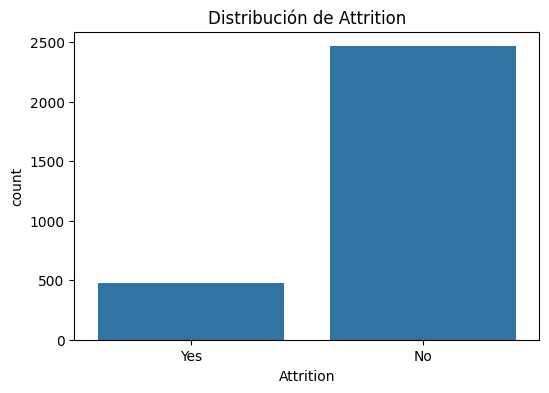

In [51]:
plt.figure(figsize=(6,4))
sns.countplot(x='Attrition', data=df)
plt.title("Distribución de Attrition")
plt.show()

## 3. Preprocesamiento de los Datos
Se prepara un pipeline para el preprocesamiento que incluya imputación (estrategia mediana o media) y escalado (se usa StandardScaler, pero se pueden probar otros como RobustScaler y MinMaxScaler).


In [52]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# Seleccionar columnas numéricas (excluyendo IDs o columnas que no se desean transformar)
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

cat_cols = df.select_dtypes(include=['object']).columns.tolist()

# Excluir columnas que no queremos procesar
cols_excluir = ['EmployeeID', 'EmployeeCount', 'Attrition']
num_cols = [col for col in num_cols if col not in cols_excluir]
cat_cols = [col for col in cat_cols if col not in cols_excluir]



### 3.1 División de Datos: Holdout (2/3 train y 1/3 test)
Se separan los datos en conjunto de entrenamiento (train) y prueba (test) para la evaluación outer.


In [53]:
# Proceed with the preprocessing and splitting
from sklearn.preprocessing import LabelEncoder

X = df.drop(columns=['Attrition'])
y = df['Attrition']
label_encoder = LabelEncoder()
y= label_encoder.fit_transform(y)
# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=1/3, random_state=SEED,stratify=y)
print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (1960, 30) Test: (980, 30)


### 3.2 Pipeline
Se prepara un pipeline numerico y categorico para luego combinarlo y tener in pipline para el preprocesamiento que incluya imputación (estrategia mediana o media) y escalado (se usa StandardScaler, pero se pueden probar otros como RobustScaler y MinMaxScaler).

In [54]:
# Definimos el pipeline categorico
categorical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])
# y ahora definimos el pipeline numerico
numeric_pipeline = Pipeline(steps=[('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())]),

# y ahora combinamos ambos pipelines
preprocessing_pipeline = ColumnTransformer(transformers=[
    ('num', numeric_pipeline, num_cols),
    ('cat', categorical_pipeline, cat_cols)
])

# Definimos el pipeline completo con KNN
knn_pipeline = Pipeline(steps=[
    ('preprocessing', preprocessing_pipeline),
    ('knn', KNeighborsClassifier())
])

## 4.Metodos Basicos: KNN y Trees


### 4.1 Modelos Básicos: KNN y Árboles
Primero se entrenan con sus parámetros por defecto y se mide el tiempo de entrenamiento y luego se entrenan con búsqueda de hiperparámetros y validación cruzada interna.

Probamos diferentes pipelines para ver si se mejora el rendimiento del modelo KNN.

In [55]:
from sklearn.model_selection import cross_val_score

param_grid = {
    'knn__n_neighbors': [3, 5, 7, 9,11,13, 15],
    'knn__weights': ['uniform', 'distance'],
    'knn__metric': ['euclidean', 'manhattan', 'minkowski']
}

inner= KFold(n_splits=3, shuffle=True, random_state=SEED)

# Defininmos diferentes pipelines numéricos
numeric_pipelines = [
    Pipeline(steps=[('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())]),
    Pipeline(steps=[('imputer', SimpleImputer(strategy='mean')), ('scaler', StandardScaler())]),
    Pipeline(steps=[('imputer', SimpleImputer(strategy='median')), ('scaler', RobustScaler())]),
    Pipeline(steps=[('imputer', SimpleImputer(strategy='mean')), ('scaler', RobustScaler())]),
    Pipeline(steps=[('imputer', SimpleImputer(strategy='median')), ('scaler', MinMaxScaler())]),
    Pipeline(steps=[('imputer', SimpleImputer(strategy='mean')), ('scaler', MinMaxScaler())])
]

# Hacemos loop sobre los pipelines numéricos manteninedo el mismo pipeline categórico
for i, numeric_pipeline in enumerate(numeric_pipelines):
    print(f"Evaluating pipeline {i+1}")

    preprocessing_pipeline = ColumnTransformer(transformers=[
        ('num', numeric_pipeline, num_cols),
        ('cat', categorical_pipeline, cat_cols)
    ])


    knn_pipeline = Pipeline(steps=[
        ('preprocessing', preprocessing_pipeline),
        ('knn', KNeighborsClassifier())
    ])

    cv_scores = cross_val_score(knn_pipeline,X_train, y_train, cv=inner, scoring='balanced_accuracy')

    print("Cross-validation balanced accuracy scores: ", cv_scores)
    print("Mean cross-validation balanced accuracy: {:.4f}".format(cv_scores.mean()))


Evaluating pipeline 1
Cross-validation balanced accuracy scores:  [0.59779195 0.58697199 0.59092664]
Mean cross-validation balanced accuracy: 0.5919
Evaluating pipeline 2
Cross-validation balanced accuracy scores:  [0.59779195 0.58697199 0.59092664]
Mean cross-validation balanced accuracy: 0.5919
Evaluating pipeline 3
Cross-validation balanced accuracy scores:  [0.58545379 0.59586847 0.61283324]
Mean cross-validation balanced accuracy: 0.5981
Evaluating pipeline 4
Cross-validation balanced accuracy scores:  [0.58545379 0.59586847 0.61283324]
Mean cross-validation balanced accuracy: 0.5981
Evaluating pipeline 5
Cross-validation balanced accuracy scores:  [0.57285925 0.59296822 0.57591469]
Mean cross-validation balanced accuracy: 0.5806
Evaluating pipeline 6
Cross-validation balanced accuracy scores:  [0.57285925 0.59296822 0.57501379]
Mean cross-validation balanced accuracy: 0.5803


Seleccionar el mejor pipeline que es RobustScaler + SimpleImputer(strategy='mean')

#### KNN Default
Entrenamos con el preprocesiamiento del pipeline elegido y parámetros por defecto.


In [56]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler, OneHotEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score

# Define the numeric pipeline
numeric_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', RobustScaler())
])

# Define the categorical pipeline
categorical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Combine the numeric and categorical pipelines
preprocessing_pipeline = ColumnTransformer(transformers=[
    ('num', numeric_pipeline, num_cols),
    ('cat', categorical_pipeline, cat_cols)
])

# Define the full pipeline with KNN
knn_pipeline = Pipeline(steps=[
    ('preprocessing', preprocessing_pipeline),
    ('knn', KNeighborsClassifier())
])

# Perform 3-fold cross-validation
cv_scores = cross_val_score(knn_pipeline,X_train, y_train, cv=inner, scoring='balanced_accuracy')

print("Cross-validation balanced accuracy scores: ", cv_scores)
print("Mean cross-validation balanced accuracy: {:.4f}".format(cv_scores.mean()))

Cross-validation balanced accuracy scores:  [0.58545379 0.59586847 0.61283324]
Mean cross-validation balanced accuracy: 0.5981


#### KNN HPO
Entrenamos con el preprocesiamiento del pipeline elegido y hiperparametros optimo utilizando GridSearchCV.

In [57]:
knn_param_grid = {
    'knn__n_neighbors': [3, 5, 7, 9,11,13, 15],
    'knn__weights': ['uniform', 'distance'],
    'knn__metric': ['euclidean', 'manhattan', 'minkowski']
}
grid_search_knnHPO = GridSearchCV(estimator=knn_pipeline, param_grid=knn_param_grid, cv=inner, scoring='balanced_accuracy')

# Fit the model
grid_search_knnHPO.fit(X_train, y_train)

# Get the best parameters and best score
best_params = grid_search_knnHPO.best_params_
best_score = grid_search_knnHPO.best_score_

print("Best parameters found: ", best_params)
print("Best cross-validation balanced accuracy: {:.4f}".format(best_score))
knn_results = grid_search_knnHPO.cv_results_['mean_test_score']

Best parameters found:  {'knn__metric': 'manhattan', 'knn__n_neighbors': 3, 'knn__weights': 'distance'}
Best cross-validation balanced accuracy: 0.7786


#### Arboles default
Entrenamos con el preprocesiamiento del pipeline elegido (aunque el scaler no tengo efecto) y parámetros por defecto.

In [58]:
from sklearn import metrics
from sklearn import tree

# Define the full pipeline with KNN
tree = Pipeline(steps=[
    ('preprocessing', preprocessing_pipeline),
    ('tree', DecisionTreeClassifier(random_state=SEED))
])

cv_scores = cross_val_score(tree, X_train, y_train, scoring='balanced_accuracy', cv = inner)
print("Cross-validation balanced accuracy scores: ", cv_scores)
print("Mean cross-validation balanced accuracy: {:.4f}".format(cv_scores.mean()))


Cross-validation balanced accuracy scores:  [0.72203884 0.72369311 0.74066924]
Mean cross-validation balanced accuracy: 0.7288


#### Arboles HPO
Entrenamos con el preprocesiamiento del pipeline elegido y hiperparametros optimo utilizando GridSearchCV.

In [59]:
from sklearn.model_selection import KFold

tree_param_grid = {
    'tree__max_depth': [None, 10,15 ,20, 30, 40, 50],
    'tree__min_samples_split': [2, 5, 10],
    'tree__min_samples_leaf': [1, 2, 4]
}

grid_search_treeHPO = GridSearchCV(estimator=tree, param_grid=tree_param_grid, cv=inner, scoring='balanced_accuracy')
start_time = time.time()
grid_search_treeHPO.fit(X_train, y_train)
end_time = time.time()
best_params = grid_search_treeHPO.best_params_
best_score = grid_search_treeHPO.best_score_
print("Best parameters found: ", best_params)
print("Best cross-validation balanced accuracy: {:.4f}".format(best_score))
tree_results = grid_search_treeHPO.cv_results_['mean_test_score']

Best parameters found:  {'tree__max_depth': 15, 'tree__min_samples_leaf': 1, 'tree__min_samples_split': 2}
Best cross-validation balanced accuracy: 0.7347


#### Visualización del efecto de los hiperparámetros

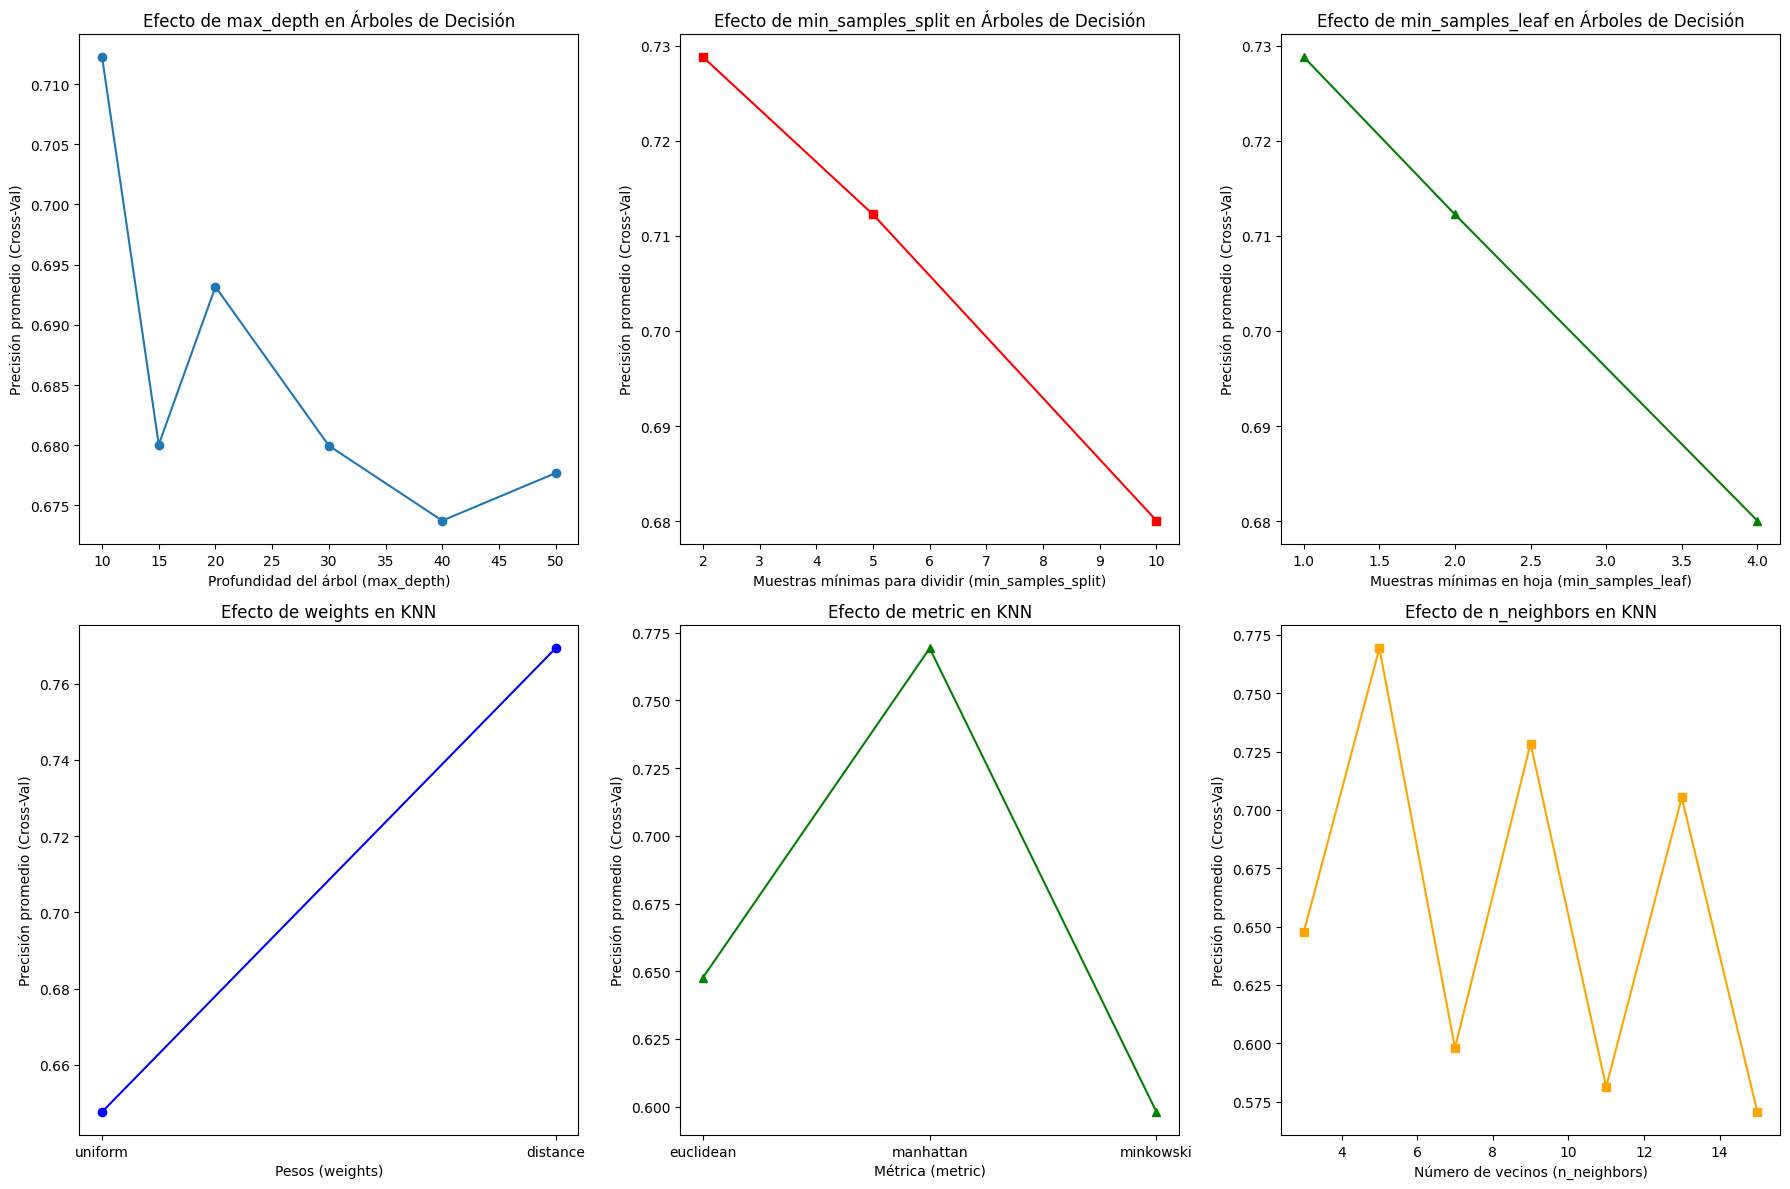

Mejor combinación en Árboles de Decisión: {'tree__max_depth': 15, 'tree__min_samples_leaf': 1, 'tree__min_samples_split': 2}
Mejor combinación en KNN: {'knn__metric': 'manhattan', 'knn__n_neighbors': 3, 'knn__weights': 'distance'}


In [60]:
plt.figure(figsize=(18, 12))

# Árboles de Decisión (comparando max_depth)
plt.subplot(2, 3, 1)
plt.plot(tree_param_grid['tree__max_depth'],
         [tree_results[i] for i in range(len(tree_param_grid['tree__max_depth']))],
         marker='o', linestyle='-')
plt.xlabel("Profundidad del árbol (max_depth)")
plt.ylabel("Precisión promedio (Cross-Val)")
plt.title("Efecto de max_depth en Árboles de Decisión")


# Árboles de Decisión (comparando min_samples_split)
plt.subplot(2, 3, 2)
plt.plot(tree_param_grid['tree__min_samples_split'],
         [tree_results[i] for i in range(len(tree_param_grid['tree__min_samples_split']))],
         marker='s', linestyle='-', color="red")
plt.xlabel("Muestras mínimas para dividir (min_samples_split)")
plt.ylabel("Precisión promedio (Cross-Val)")
plt.title("Efecto de min_samples_split en Árboles de Decisión")

# Árboles de Decisión (comparando min_samples_leaf)
plt.subplot(2, 3, 3)
plt.plot(tree_param_grid['tree__min_samples_leaf'],
         [tree_results[i] for i in range(len(tree_param_grid['tree__min_samples_leaf']))],
         marker='^', linestyle='-', color="green")
plt.xlabel("Muestras mínimas en hoja (min_samples_leaf)")
plt.ylabel("Precisión promedio (Cross-Val)")
plt.title("Efecto de min_samples_leaf en Árboles de Decisión")

plt.subplot(2, 3, 4)
weights = knn_param_grid['knn__weights']
mean_scores_weights = [knn_results[i] for i in range(len(weights))]
plt.plot(weights, mean_scores_weights, marker='o', linestyle='-', color="blue")
plt.xlabel("Pesos (weights)")
plt.ylabel("Precisión promedio (Cross-Val)")
plt.title("Efecto de weights en KNN")

# KNN (comparing metric)
plt.subplot(2, 3, 5)
metrics = knn_param_grid['knn__metric']
mean_scores_metrics = [knn_results[i] for i in range(len(metrics))]
plt.plot(metrics, mean_scores_metrics, marker='^', linestyle='-', color="green")
plt.xlabel("Métrica (metric)")
plt.ylabel("Precisión promedio (Cross-Val)")
plt.title("Efecto de metric en KNN")

# KNN (comparando n_neighbors)
plt.subplot(2, 3, 6)
plt.plot(knn_param_grid['knn__n_neighbors'],
         [knn_results[i] for i in range(len(knn_param_grid['knn__n_neighbors']))],
         marker='s', linestyle='-', color="orange")
plt.xlabel("Número de vecinos (n_neighbors)")
plt.ylabel("Precisión promedio (Cross-Val)")
plt.title("Efecto de n_neighbors en KNN")


plt.tight_layout()
plt.show()

# Imprimir los mejores parametros para KNN y arboles
print(f"Mejor combinación en Árboles de Decisión: {grid_search_treeHPO.best_params_}")
print(f"Mejor combinación en KNN: {grid_search_knnHPO.best_params_}")

### 4.2 Modelos Avanzados: Regresión Logística y SVM

#### Regresión Logística Default
Entrenamos un modelo de Regresión Logística con parámetros por defecto y medimos el tiempo de entrenamiento.


In [61]:
# Creamos un pipeline que utiliza el preprocesamiento ya definido y añade el modelo de Regresión Logística
log_reg_pipeline = Pipeline(steps=[
    ('preprocessing', preprocessing_pipeline),
    ('log_reg', LogisticRegression(max_iter=1000, solver='liblinear', random_state=SEED))
])

# Entrenamiento del modelo con parámetros por defecto
start_time = time.time()
log_reg_pipeline.fit(X_train, y_train)
log_reg_time = time.time() - start_time
print("Tiempo de entrenamiento Regresión Logística (default): {:.4f} segundos".format(log_reg_time))

# Evaluación en el conjunto de entrenamiento
y_pred_log = log_reg_pipeline.predict(X_train)
print("Balanced Accuracy Regresión Logística (default):", balanced_accuracy_score(y_train, y_pred_log))

Tiempo de entrenamiento Regresión Logística (default): 0.0225 segundos
Balanced Accuracy Regresión Logística (default): 0.618251255043272


#### Regresión Logística HPO
Realizamos una búsqueda de hiperparámetros para optimizar el modelo de Regresión Logística.
Ajustamos el parámetro de regularización C y la penalización (l1 y l2).


In [62]:
# Definimos el grid de hiperparámetros para la Regresión Logística
log_reg_param_grid = {
    'log_reg__C': [0.01, 0.1, 1, 10, 100],
    'log_reg__penalty': ['l1', 'l2']  # Usamos 'liblinear', que soporta ambas penalizaciones.
}

# Realizamos la búsqueda de hiperparámetros con validación cruzada interna
grid_search_log = GridSearchCV(estimator=log_reg_pipeline, 
                               param_grid=log_reg_param_grid, 
                               cv=inner, 
                               scoring='balanced_accuracy')
grid_search_log.fit(X_train, y_train)

print("Mejores parámetros para Regresión Logística:", grid_search_log.best_params_)
print("Mejor balanced accuracy Regresión Logística:", grid_search_log.best_score_)

Mejores parámetros para Regresión Logística: {'log_reg__C': 10, 'log_reg__penalty': 'l1'}
Mejor balanced accuracy Regresión Logística: 0.6106094039880413


#### SVM Default
Entrenamos un modelo SVM con parámetros por defecto y medimos el tiempo de entrenamiento.

In [63]:
# Creamos un pipeline para SVM que incluye el preprocesamiento
svm_pipeline_default = Pipeline(steps=[
    ('preprocessing', preprocessing_pipeline),
    ('svm', SVC(random_state=SEED))
])

# Entrenamiento del modelo SVM con parámetros por defecto
start_time = time.time()
svm_pipeline_default.fit(X_train, y_train)
svm_time = time.time() - start_time
print("Tiempo de entrenamiento SVM (default): {:.4f} segundos".format(svm_time))

# Evaluación en el conjunto de entrenamiento
y_pred_svm = svm_pipeline_default.predict(X_train)
print("Balanced Accuracy SVM (default):", balanced_accuracy_score(y_train, y_pred_svm))

Tiempo de entrenamiento SVM (default): 0.0546 segundos
Balanced Accuracy SVM (default): 0.7595552681018818


#### SVM HPO
- Realizamos la búsqueda de hiperparámetros para optimizar el modelo SVM.
- Ajustamos el parámetro C y el tipo de kernel (lineal y RBF).

In [64]:
# Creamos nuevamente el pipeline para SVM (para mayor claridad)
svm_pipeline = Pipeline(steps=[
    ('preprocessing', preprocessing_pipeline),
    ('svm', SVC(random_state=SEED))
])

# Definimos el grid de hiperparámetros para SVM
svm_param_grid = {
    'svm__C': [0.1, 1, 10],
    'svm__kernel': ['linear', 'rbf']
}

# Búsqueda de hiperparámetros con validación cruzada interna
grid_search_svm = GridSearchCV(estimator=svm_pipeline, 
                               param_grid=svm_param_grid, 
                               cv=inner, 
                               scoring='balanced_accuracy')
grid_search_svm.fit(X_train, y_train)

print("Mejores parámetros para SVM:", grid_search_svm.best_params_)
print("Mejor balanced accuracy SVM:", grid_search_svm.best_score_)

Mejores parámetros para SVM: {'svm__C': 10, 'svm__kernel': 'rbf'}
Mejor balanced accuracy SVM: 0.7916828428759998
